# Baseline Catboost Model

In [11]:
%%capture
! pip install catboost seaborn pandas numpy matplotlib

In [12]:
import pandas as pd, numpy as np, \
seaborn as sns, matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

merged = pd.read_csv('merged.csv', index_col = 0)
merged.head()

,player_id,name_x,position_x,team_x,season_x,conference,usage_passing_downs,usage_standard_downs,usage_third_down,usage_second_down,usage_first_down,usage_rush,usage_var_pass,usage_overall,avg_ppa_passing_downs,avg_ppa_standard_downs,avg_ppa_third_down,avg_ppa_second_down,avg_ppa_first_down,avg_ppa_rush,avg_ppa_var_pass,avg_ppa_all,total_ppa_passing_downs,total_ppa_standard_downs,total_ppa_third_down,total_ppa_second_down,total_ppa_first_down,total_ppa_rush,total_ppa_var_pass,total_ppa_all,fumbles_FUM,fumbles_LOST,fumbles_REC,passing_ATT,passing_COMPLETIONS,passing_INT,passing_PCT,passing_TD,passing_YDS,passing_YPA,receiving_LONG,receiving_REC,receiving_TD,receiving_YDS,receiving_YPR,rushing_ATT,rushing_LONG,rushing_TD,rushing_YDS,rushing_YPC,college_athlete_id,nfl_athlete_id,college_id,college_team,college_conference,nfl_team_id,nfl_team,position_y,name_y,year,round_x,pick_number,overall,height_in,weight_lbs,pre_draft_position_ranking,pre_draft_grade,pfr_player_id,cfb_player_id,season_y,round_y,pick,team_y,pfr_player_name,position,category,college,w_av,car_av,dr_av,ht,wt,forty,bench,vertical,broad_jump,cone,shuttle,pfr_id,birth_date,height,weight,rookie_season,last_season,birth_year,age
0,100009,Johnny Jackson,WR,Arizona,2015,PAC,0.104000,0.049000,0.094000,0.065000,0.055000,0.000000,0.133000,0.065000,0.953000,0.413000,1.314000,0.839000,0.415000,NaN,0.674,0.6740,28.600000,13.214000,22.345000,16.772000,9.542000,0.000000,41.813000,41.813000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,50.0,5.0,612.0,12.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,102597,Will Rogers,QB,Washington,2024,B1G,0.670000,0.458333,0.652167,0.532667,0.454333,0.060167,0.888000,0.520333,0.443833,0.188333,0.426833,0.438667,0.138167,-0.1675,0.313,0.2910,57.095833,43.996000,36.587833,45.864333,24.582667,-3.056667,104.148667,101.092333,4.5,2.166667,0.5,336.166667,226.333333,6.166667,0.666333,16.833333,2431.5,7.333333,NaN,NaN,NaN,NaN,NaN,34.000000,17.500000,0.333333,-71.333333,-1.916667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,107494,Trey Sanders,RB,TCU,2024,B12,0.043400,0.068400,0.047267,0.071533,0.058267,0.119733,0.008867,0.060600,0.646133,0.010467,0.280800,-0.090933,-0.006867,0.1442,NaN,0.1604,2.071933,2.040267,3.381200,-0.835133,-0.067467,3.438600,0.674133,4.112733,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.466667,15.333333,2.066667,128.733333,4.173333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,109907,Jon Lee,RB,Air Force,2014,MWC,0.035000,0.025000,0.015000,0.057000,0.015000,0.023000,0.052000,0.028000,0.630000,-0.128000,-0.363000,0.173000,0.222000,0.1790,0.015,0.1240,1.890000,-0.770000,-0.363000,1.040000,0.444000,1.076000,0.044000,1.120000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,2.0,0.0,12.0,6.0,6.000000,32.000000,0.000000,39.000000,6.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,136429,Cedric Patterson III,WR,Rice,2022,CUSA,0.077333,0.033667,0.116667,0.018000,0.045000,0.022667,0.086667,0.050667,0.224000,0.066333,0.166000,NaN,0.191333,0.1360,0.150,0.1760,6.349333,6.364667,3.909000,2.029667,6.775333,0.465333,12.248333,12.714000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.666667,15.333333,0.333333,16.000000,7.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
merged.columns

Index(['player_id', 'name_x', 'position_x', 'team_x', 'season_x', 'conference',
       'usage_passing_downs', 'usage_standard_downs', 'usage_third_down',
       'usage_second_down', 'usage_first_down', 'usage_rush', 'usage_var_pass',
       'usage_overall', 'avg_ppa_passing_downs', 'avg_ppa_standard_downs',
       'avg_ppa_third_down', 'avg_ppa_second_down', 'avg_ppa_first_down',
       'avg_ppa_rush', 'avg_ppa_var_pass', 'avg_ppa_all',
       'total_ppa_passing_downs', 'total_ppa_standard_downs',
       'total_ppa_third_down', 'total_ppa_second_down', 'total_ppa_first_down',
       'total_ppa_rush', 'total_ppa_var_pass', 'total_ppa_all', 'fumbles_FUM',
       'fumbles_LOST', 'fumbles_REC', 'passing_ATT', 'passing_COMPLETIONS',
       'passing_INT', 'passing_PCT', 'passing_TD', 'passing_YDS',
       'passing_YPA', 'receiving_LONG', 'receiving_REC', 'receiving_TD',
       'receiving_YDS', 'receiving_YPR', 'rushing_ATT', 'rushing_LONG',
       'rushing_TD', 'rushing_YDS', 'rushing_YPC', 

In [14]:
# filling in NAs for counting stats (they should all be zero)
merged.fillna(value={
    'fumbles_FUM' : 0,
    'fumbles_LOST' : 0,
    'fumbles_REC' : 0,
    'passing_ATT': 0,
    'passing_COMPLETIONS' : 0,
    'passing_PCT' : 0,
    'passing_INT' : 0,
    'passing_TD' : 0,
    'passing_YDS' : 0,
    'passing_YPA' : 0,
    'receiving_LONG' : 0,
    'receiving_REC' : 0,
    'receiving_TD' : 0,
    'receiving_YDS' : 0,
    'receiving_YPR' : 0,
    'rushing_ATT' : 0,
    'rushing_LONG' : 0,
    'rushing_TD' : 0,
    'rushing_YDS' : 0,
    'rushing_YPC' : 0
},
              inplace=True)

merged.dropna(axis = 0, subset = 'overall', inplace=True)

merged['INT_pct'] = merged['passing_INT']/merged['passing_ATT']

merged.fillna(value={'INT_pct' : 0}, inplace=True)

# Taking yearly average of wAV so players drafted earlier don't have higher values
# since wAV is a cumulative stat
# (in other words, I'm turning it into a rate stat)
merged['adjusted_w_av'] = (merged['w_av']/
 ((merged['last_season'] + 1) - merged['year'])
)

X = merged[['position_x', 'usage_overall', 'avg_ppa_all', 'total_ppa_all','conference',
            'fumbles_FUM', 'fumbles_LOST', 'passing_ATT', 'passing_COMPLETIONS',
            'passing_PCT', 'INT_pct','passing_TD', 'passing_YDS','passing_YPA', 'receiving_REC',
            'receiving_TD', 'receiving_YDS', 'receiving_YPR', 'rushing_ATT', 'rushing_TD',
            'rushing_YDS', 'rushing_YPC', 'age', 'height', 'weight']]

y = merged['adjusted_w_av'].fillna(value=0)


X

,position_x,usage_overall,avg_ppa_all,total_ppa_all,conference,fumbles_FUM,fumbles_LOST,passing_ATT,passing_COMPLETIONS,passing_PCT,INT_pct,passing_TD,passing_YDS,passing_YPA,receiving_REC,receiving_TD,receiving_YDS,receiving_YPR,rushing_ATT,rushing_TD,rushing_YDS,rushing_YPC,age,height,weight
10,WR,0.114400,0.792400,79.568000,B1G,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,66.200000,10.300000,1027.400000,15.490000,0.000000,0.000000,0.000000,0.000000,22.0,73.0,208.0
13,WR,0.026000,-0.166000,-1.163000,SEC,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,1.000000,0.000000,-3.000000,-3.000000,2.000000,0.000000,30.000000,15.000000,25.0,72.0,190.0
15,QB,0.475000,0.341000,173.161000,B12,0.000000,0.000000,428.0,270.0,0.631,0.016355,29.0,3855.0,9.00,0.000000,0.000000,0.000000,0.000000,84.000000,6.000000,101.000000,1.200000,24.0,75.0,226.0
37,TE,0.036000,0.481000,12.016000,PAC,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,21.000000,2.000000,197.000000,9.400000,0.000000,0.000000,0.000000,0.000000,23.0,76.0,250.0
45,QB,0.524000,0.098000,44.653000,B1G,0.000000,0.000000,392.0,228.0,0.582,0.028061,7.0,2214.0,5.60,1.000000,1.000000,17.000000,17.000000,68.000000,5.000000,-123.000000,-1.800000,24.0,75.0,220.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10096,RB,0.266167,0.161167,33.282500,ACC,1.666667,0.833333,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,47.500000,2.500000,354.000000,7.133333,202.166667,11.166667,910.500000,4.833333,21.0,72.0,201.0
10554,RB,0.214000,0.273500,50.862000,SEC,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,16.166667,0.333333,133.833333,8.366667,174.000000,14.333333,1012.666667,5.933333,21.0,68.0,201.0
10645,WR,0.100667,1.259333,68.872667,MWC,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,60.333333,9.000000,916.000000,15.200000,0.000000,0.000000,0.000000,0.000000,22.0,72.0,195.0
10661,TE,0.127500,0.784167,77.936500,MAC,0.000000,0.000000,1.5,0.5,0.250,0.000000,0.0,4.5,2.25,76.333333,7.166667,1019.000000,13.250000,10.833333,1.166667,55.000000,5.450000,21.0,76.0,241.0


In [15]:
X.isna().sum()

position_x             0
usage_overall          0
avg_ppa_all            0
total_ppa_all          0
conference             0
fumbles_FUM            0
fumbles_LOST           0
passing_ATT            0
passing_COMPLETIONS    0
passing_PCT            0
INT_pct                0
passing_TD             0
passing_YDS            0
passing_YPA            0
receiving_REC          0
receiving_TD           0
receiving_YDS          0
receiving_YPR          0
rushing_ATT            0
rushing_TD             0
rushing_YDS            0
rushing_YPC            0
age                    4
height                 4
weight                 4
dtype: int64

In [16]:
na_idx = X[X.isna().any(axis=1)].index
print(na_idx)

X_nona = X.drop(index=na_idx, inplace = False)
y_nona = y.drop(index=na_idx, inplace=False)

Index([114, 229, 4314, 7510], dtype='int64')


In [17]:
y_nona

10       1.500000
13       0.000000
15       1.000000
37       0.000000
45       1.454545
           ...   
10096    1.000000
10554    3.000000
10645    0.000000
10661    5.000000
11077    2.000000
Name: adjusted_w_av, Length: 790, dtype: float64

In [18]:
# checking for NA valuesi n y_nona
y_nona.isna().sum()

np.int64(0)

In [19]:
y_nona.value_counts()

adjusted_w_av
0.000000     175
1.000000      49
0.500000      39
2.000000      36
3.000000      23
            ... 
10.333333      1
13.333333      1
7.750000       1
12.000000      1
7.666667       1
Name: count, Length: 185, dtype: int64

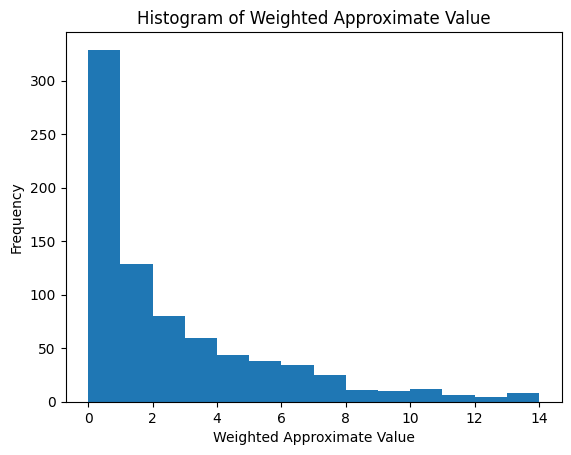

In [20]:
bin_width = 1

bins = np.arange(min(y_nona), max(y_nona) + bin_width, bin_width)

plt.hist(y_nona, bins = bins)
plt.ylabel('Frequency')
plt.xlabel('Weighted Approximate Value')
plt.title('Histogram of Weighted Approximate Value')
plt.show()

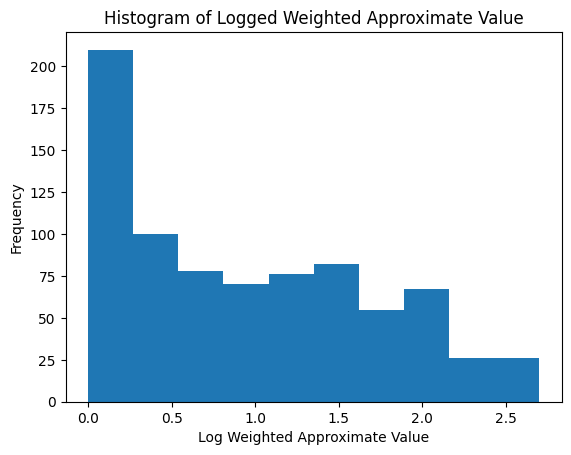

In [21]:
y_log = y_nona.copy()
y_log = np.log(y_log + 1)

plt.hist(y_log)
plt.ylabel('Frequency')
plt.xlabel('Log Weighted Approximate Value')
plt.title('Histogram of Logged Weighted Approximate Value')
plt.show()

In [22]:
y_log.value_counts()

adjusted_w_av
0.000000    175
0.693147     49
0.405465     39
1.098612     36
1.386294     23
           ... 
2.427748      1
2.662588      1
2.169054      1
2.564949      1
2.159484      1
Name: count, Length: 185, dtype: int64

In [23]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split


train_x, test_x, train_y, test_y = train_test_split(X_nona, y_nona, test_size = 0.3)

# num_cols = train_x.select_dtypes(include=np.number).columns
# cat_cols = train_x.select_dtypes(include=['str', 'category']).columns


# # Create transformer
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), num_cols)
#     ],
#     remainder='passthrough',
#     verbose_feature_names_out=False
# )

# preprocessor.set_output(transform="pandas")

# # Fit on training data, transform both
# train_x = preprocessor.fit_transform(train_x)
# test_x = preprocessor.transform(test_x)

In [24]:
train_x

,position_x,usage_overall,avg_ppa_all,total_ppa_all,conference,fumbles_FUM,fumbles_LOST,passing_ATT,passing_COMPLETIONS,passing_PCT,INT_pct,passing_TD,passing_YDS,passing_YPA,receiving_REC,receiving_TD,receiving_YDS,receiving_YPR,rushing_ATT,rushing_TD,rushing_YDS,rushing_YPC,age,height,weight
2474,WR,0.061700,0.527400,26.925300,ACC,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,29.700000,4.500000,361.800000,11.940000,0.000000,0.000000,0.000000,0.000000,23.0,69.0,185.0
3918,WR,0.149000,0.565333,75.404333,Ind,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,76.333333,10.000000,1276.333333,16.666667,0.000000,0.000000,0.000000,0.000000,22.0,76.0,223.0
9243,WR,0.077800,0.655300,33.486800,B12,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,42.600000,2.900000,497.500000,12.040000,3.300000,0.200000,26.800000,6.260000,23.0,68.0,174.0
1100,RB,0.229000,0.249000,53.800000,SEC,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,15.000000,1.000000,180.000000,12.000000,194.000000,11.000000,979.000000,5.000000,22.0,73.0,223.0
317,TE,0.033000,0.971000,16.504000,SEC,0.000000,0.000000,1.0,1.0,1.000000,0.000000,0.0,-1.000000,-1.000000,11.000000,3.000000,145.000000,13.200000,1.000000,0.000000,1.000000,1.000000,22.0,78.0,271.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
969,TE,0.070000,0.438500,27.987667,MAC,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,38.166667,2.000000,412.833333,10.600000,0.000000,0.000000,0.000000,0.000000,24.0,77.0,252.0
5816,TE,0.094667,0.833333,48.765333,SEC,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,40.000000,7.833333,613.500000,17.000000,0.000000,0.000000,0.000000,0.000000,21.0,78.0,250.0
7662,QB,0.430800,0.446500,165.119200,ACC,3.200000,0.900000,349.0,230.8,0.687200,0.019484,21.2,2942.200000,8.960000,0.000000,0.000000,0.000000,0.000000,37.900000,1.200000,-46.300000,-0.920000,23.0,75.0,218.0
5825,QB,0.496500,0.461500,203.093500,ACC,3.333333,2.333333,369.0,248.0,0.673833,0.015808,29.0,3344.833333,9.066667,1.000000,0.000000,2.000000,2.000000,78.333333,7.166667,318.666667,3.833333,22.0,78.0,220.0


In [25]:
import numpy as np

class GammaObjective(object):
    def calc_ders_range(self, approxes, targets, weights):
        # Numba loves simple, explicit loops. It will compile this to C-speed.
        result = []
        
        for i in range(len(targets)):
            # 1. Get the raw prediction and clip it manually 
            # (Numba handles basic if/else much better than np.clip)
            approx = approxes[i]
            if approx > 20.0:
                approx = 20.0
            elif approx < -20.0:
                approx = -20.0
                
            # Apply log-link
            mu = np.exp(approx)
            
            # 2. Calculate derivatives
            der1 = (targets[i] / mu) - 1.0
            der2 = -(targets[i] / mu)
            
            # 3. Apply weights if they exist
            if weights is not None:
                der1 *= weights[i]
                der2 *= weights[i]
                
            # 4. Append as a tuple
            result.append((der1, der2))
            
        return result

class GammaRMSEMetric(object):
    def get_final_error(self, error, weight):
        # The evaluate method returns the Sum of Squared Errors.
        # Here, we divide by the total weight (or count) and take the square root.
        return np.sqrt(error / (weight + 1e-38))

    def is_max_optimal(self):
        # We are minimizing RMSE, so max is not optimal
        return False

    def evaluate(self, approxes, targets, weights):
        # Numba-friendly loop for evaluation
        approx = approxes[0]
        
        error_sum = 0.0
        weight_sum = 0.0
        
        for i in range(len(targets)):
            # 1. Get raw prediction and clip to prevent np.exp() overflow
            z = approx[i]
            if z > 20.0:
                z = 20.0
            elif z < -20.0:
                z = -20.0
                
            # 2. Transform back to original scale (The expected value)
            mu = np.exp(z)
            
            # 3. Calculate the Squared Error: (y - mu)^2
            sq_error = (targets[i] - mu) ** 2
            
            # 4. Accumulate sums
            if weights is not None:
                w = weights[i]
                error_sum += sq_error * w
                weight_sum += w
            else:
                error_sum += sq_error
                weight_sum += 1.0
                
        # Return the total Sum of Squared Errors and the total weight
        return error_sum, weight_sum

In [26]:
from catboost import CatBoostRegressor

# finds categorical features
cat_features = train_x.select_dtypes(include=['str', 'category']).columns
cat_indices = [train_x.columns.get_loc(col) for col in cat_features]

model = CatBoostRegressor(
    iterations=2000,
    depth=3,
    learning_rate=0.05,
    loss_function=GammaObjective(),
    eval_metric = GammaRMSEMetric(),
    l2_leaf_reg = 10,
    verbose=100
)

model.fit(
    train_x,
    (train_y + 1),
    eval_set = (test_x, test_y + 1),
    cat_features=cat_indices # assigns categorical features
)

preds = model.predict(test_x)

/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


0:	learn: 3.7920759	test: 3.8495393	best: 3.8495393 (0)	total: 73.2ms	remaining: 2m 26s
100:	learn: 2.5699313	test: 2.8008641	best: 2.8008641 (100)	total: 1.32s	remaining: 24.8s
200:	learn: 2.3361785	test: 2.7046961	best: 2.7046961 (200)	total: 1.98s	remaining: 17.7s
300:	learn: 2.1999342	test: 2.7057660	best: 2.6948467 (227)	total: 2.6s	remaining: 14.7s
400:	learn: 2.1083195	test: 2.6940735	best: 2.6940735 (400)	total: 3.2s	remaining: 12.8s
500:	learn: 2.0174176	test: 2.6954823	best: 2.6940735 (400)	total: 4.06s	remaining: 12.1s
600:	learn: 1.9370364	test: 2.7020686	best: 2.6940735 (400)	total: 4.71s	remaining: 11s
700:	learn: 1.8768959	test: 2.6979999	best: 2.6940735 (400)	total: 5.4s	remaining: 10s
800:	learn: 1.8304678	test: 2.7177412	best: 2.6940735 (400)	total: 6.16s	remaining: 9.22s
900:	learn: 1.7747354	test: 2.7274450	best: 2.6940735 (400)	total: 6.84s	remaining: 8.35s
1000:	learn: 1.7256413	test: 2.7366493	best: 2.6940735 (400)	total: 7.53s	remaining: 7.51s
1100:	learn: 1.678

In [27]:
print(f"{"="*10}Raw Predictions{"="*10}\n{preds}")
print(f"{"="*10}Exponentiated Predictions{"="*10}\n{np.exp(preds) - 1}")

==========Raw Predictions==========
[0.71343213 0.58683275 1.48133987 1.16180711 0.97956632 1.17262637
 1.31133218 1.30065326 1.2566423  1.51285709 1.21217059 0.93730647
 0.7370335  0.83880044 0.62668633 1.37180398 0.8319956  1.24378356
 0.8793579  0.73807434 1.53361319 0.65052367 1.0629019  1.40035299
 1.47930066 1.31904914 0.77703118 1.36867984 1.13740999 1.28509399
 0.86956149 0.59138891 0.77706193 1.29099795 1.66296072 1.41570753
 1.33387768 0.60218027 0.67412683 1.0758982  1.24748557 1.44457105
 0.62048262 0.58606706 1.22876704 1.38470131 1.19186765 1.40260899
 0.56362238 0.74447556 1.43641129 1.40973053 1.04109338 0.446801
 1.04263639 1.58511614 0.69911279 1.48602875 0.74466048 0.94686388
 1.31712867 1.34351779 1.45616308 1.14603114 0.91744517 1.28656206
 1.59772787 0.78205232 1.09310497 0.76565842 1.17707731 1.19408862
 1.69959542 1.23240257 0.75800405 0.59687758 0.68016625 1.79229707
 0.8661062  0.80915552 1.03327926 0.7685849  0.80838858 0.5990479
 0.98481251 0.63649121 0.5484

In [28]:
from sklearn.metrics import root_mean_squared_error as rmse
preds_exp = np.exp(preds) - 1
#test_y_exp = np.exp(test_y) - 1

test_rmse = rmse(test_y, preds_exp)

print(f"Test RMSE: {test_rmse:.2f}")

Test RMSE: 2.69


In [29]:
from catboost import cv, Pool

cv_dataset = Pool(data=train_x, label=train_y, cat_features=cat_indices)

params = {
    "iterations": 2000,
    "depth": 3,
    "loss_function": GammaObjective(),
    "eval_metric": GammaRMSEMetric(),
    "l2_leaf_reg": 10,
    "verbose": 100
}

# This will run cleanly without cloning errors
cv_results = cv(
    pool=cv_dataset,
    params=params,
    fold_count=5,
    early_stopping_rounds=50, 
    return_models=False 
)

print(f"\nBest Test RMSE: {cv_results['test-GammaRMSEMetric-mean'].min():.4f}")

Training on fold [0/5]
0:	learn: 3.3946888	test: 2.6006140	best: 2.6006140 (0)	total: 4.89ms	remaining: 9.78s


/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:7283: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  return _cv(


100:	learn: 2.7448669	test: 2.3659513	best: 2.3613849 (76)	total: 411ms	remaining: 7.72s

bestTest = 2.361384874
bestIteration = 76

Training on fold [1/5]
0:	learn: 3.1575181	test: 3.6007532	best: 3.6007532 (0)	total: 3.74ms	remaining: 7.49s
100:	learn: 2.6264679	test: 3.0898278	best: 3.0898278 (100)	total: 471ms	remaining: 8.86s
200:	learn: 2.4478038	test: 3.0110904	best: 3.0081076 (179)	total: 861ms	remaining: 7.71s
300:	learn: 2.3212533	test: 2.9507043	best: 2.9500552 (296)	total: 1.42s	remaining: 7.99s
400:	learn: 2.2229373	test: 2.9405987	best: 2.9337011 (351)	total: 1.9s	remaining: 7.57s

bestTest = 2.933701057
bestIteration = 351

Training on fold [2/5]
0:	learn: 3.2219771	test: 3.3658367	best: 3.3658367 (0)	total: 3.77ms	remaining: 7.54s
100:	learn: 2.7042123	test: 2.8295188	best: 2.8295188 (100)	total: 383ms	remaining: 7.21s
200:	learn: 2.5152750	test: 2.7179864	best: 2.7175082 (198)	total: 815ms	remaining: 7.3s
300:	learn: 2.4193792	test: 2.6913319	best: 2.6905095 (294)	tota

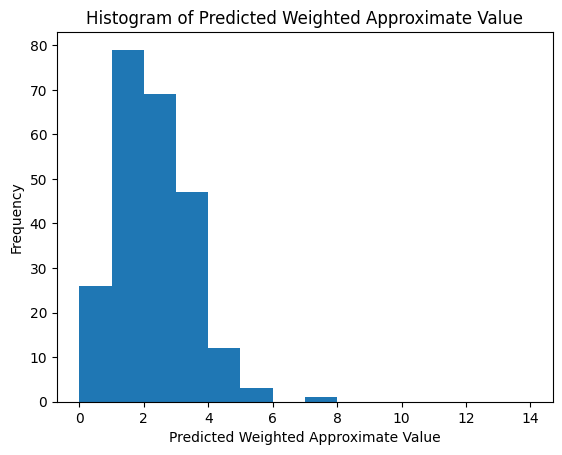

In [30]:
plt.hist(preds_exp, bins = bins)
plt.ylabel('Frequency')
plt.xlabel('Predicted Weighted Approximate Value')
plt.title('Histogram of Predicted Weighted Approximate Value')
plt.show()

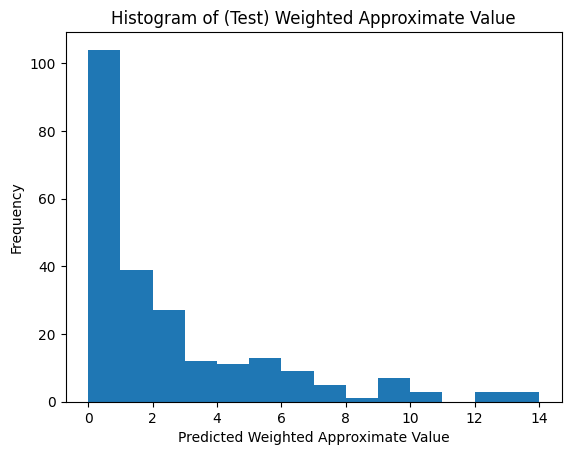

In [31]:
plt.hist(test_y, bins = bins)
plt.ylabel('Frequency')
plt.xlabel('Predicted Weighted Approximate Value')
plt.title('Histogram of (Test) Weighted Approximate Value')
plt.show()

In [32]:
from sklearn.model_selection import KFold
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error as rmse # Re-import rmse here to ensure it's a function

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []

# Define numerical and categorical columns for the preprocessor, based on X_nona structure.
# These were implicitly identified in the previous preprocessing step (NYVxNwb6PztL).
# Ensuring they are explicitly available here for clarity and correctness.
num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include='object').columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Create a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original) # Apply StandardScaler to numerical columns
        ],
        remainder='passthrough', # Keep categorical columns as they are for CatBoost
        verbose_feature_names_out=False
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    # Identify categorical feature indices in the processed data for CatBoost
    cat_features_in_processed_data = X_train_processed.select_dtypes(include=['object', 'category']).columns
    cat_indices_fold = [X_train_processed.columns.get_loc(col) for col in cat_features_in_processed_data]

    model = CatBoostRegressor(
        iterations=2000,
        depth=6,
        learning_rate=0.05,
        loss_function='RMSE',
        verbose=1000,
        l2_leaf_reg = 10,
        random_seed=101 # Added random_seed for reproducibility
    )

    model.fit(
        X_train_processed,
        y_train_fold,
        eval_set = (X_val_processed, y_val_fold),
        cat_features=cat_indices_fold
    )

    preds = model.predict(X_val_processed)

    preds_exp = np.exp(preds) - 1
    test_y_exp = np.exp(y_val_fold) - 1

    test_rmse = rmse(test_y_exp, preds_exp)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

/tmp/ipykernel_15327/2467828378.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_original = X_nona.select_dtypes(include='object').columns
/tmp/ipykernel_15327/2467828378.py:37: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-se

0:	learn: 0.7615862	test: 0.8176041	best: 0.8176041 (0)	total: 4.42ms	remaining: 8.84s


1000:	learn: 0.3062265	test: 0.7367422	best: 0.7231914 (173)	total: 3.35s	remaining: 3.34s
1999:	learn: 0.1839003	test: 0.7409859	best: 0.7231914 (173)	total: 7.26s	remaining: 0us

bestTest = 0.7231913745
bestIteration = 173

Shrink model to first 174 iterations.
0:	learn: 0.7641433	test: 0.8024851	best: 0.8024851 (0)	total: 3.68ms	remaining: 7.35s


/tmp/ipykernel_15327/2467828378.py:37: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features_in_processed_data = X_train_processed.select_dtypes(include=['object', 'category']).columns


1000:	learn: 0.3133638	test: 0.7354668	best: 0.7345717 (790)	total: 4.11s	remaining: 4.1s
1999:	learn: 0.1841648	test: 0.7317029	best: 0.7314573 (1794)	total: 8.03s	remaining: 0us

bestTest = 0.7314572866
bestIteration = 1794

Shrink model to first 1795 iterations.
0:	learn: 0.7684157	test: 0.7630714	best: 0.7630714 (0)	total: 4.4ms	remaining: 8.8s


...

1000:	learn: 0.3228559	test: 0.6910998	best: 0.6728170 (520)	total: 4.17s	remaining: 4.16s
1999:	learn: 0.1917386	test: 0.7008309	best: 0.6728170 (520)	total: 7.54s	remaining: 0us

bestTest = 0.6728169695
bestIteration = 520

Shrink model to first 521 iterations.
0:	learn: 0.7645688	test: 0.7904863	best: 0.7904863 (0)	total: 3.7ms	remaining: 7.39s


/tmp/ipykernel_15327/2467828378.py:37: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features_in_processed_data = X_train_processed.select_dtypes(include=['object', 'category']).columns


1000:	learn: 0.3038558	test: 0.6766115	best: 0.6622355 (182)	total: 3.52s	remaining: 3.52s
1999:	learn: 0.1778878	test: 0.6932175	best: 0.6622355 (182)	total: 7.74s	remaining: 0us

bestTest = 0.6622354789
bestIteration = 182

Shrink model to first 183 iterations.
0:	learn: 0.7748091	test: 0.6915749	best: 0.6915749 (0)	total: 3.39ms	remaining: 6.78s


/tmp/ipykernel_15327/2467828378.py:37: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features_in_processed_data = X_train_processed.select_dtypes(include=['object', 'category']).columns


1000:	learn: 0.3197422	test: 0.6773307	best: 0.6636017 (381)	total: 3.54s	remaining: 3.53s
1999:	learn: 0.1857171	test: 0.6891427	best: 0.6636017 (381)	total: 7.03s	remaining: 0us

bestTest = 0.6636016899
bestIteration = 381

Shrink model to first 382 iterations.
CV RMSE: 2.67


In [33]:
y_log.describe()

count    790.000000
mean       0.926980
std        0.772268
min        0.000000
25%        0.223144
50%        0.810930
75%        1.545783
max        2.699682
Name: adjusted_w_av, dtype: float64

# RandomForest

In [34]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error as rmse # Re-import rmse here to ensure it's a function

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []

# Define numerical and categorical columns for the preprocessor, based on X_nona structure.
# These were implicitly identified in the previous preprocessing step (NYVxNwb6PztL).
# Ensuring they are explicitly available here for clarity and correctness.
num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include='object').columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Create a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original), # Apply StandardScaler to numerical columns
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    # Identify categorical feature indices in the processed data for CatBoost
    cat_features_in_processed_data = X_train_processed.select_dtypes(include=['object', 'category']).columns
    cat_indices_fold = [X_train_processed.columns.get_loc(col) for col in cat_features_in_processed_data]

    model = RandomForestRegressor(
        n_estimators = 1000,
        max_features = 'sqrt'
    )

    model.fit(
        X_train_processed,
        y_train_fold
    )

    preds = model.predict(X_val_processed)

    preds_exp = np.exp(preds) - 1
    test_y_exp = np.exp(y_val_fold) - 1

    test_rmse = rmse(test_y_exp, preds_exp)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

/tmp/ipykernel_15327/2447692212.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_original = X_nona.select_dtypes(include='object').columns


CV RMSE: 2.75


# **XGBoost**

In [35]:
%%capture
! pip install xgboost

In [36]:
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
import xgboost as xgb
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error as rmse # Re-import rmse here to ensure it's a function

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []

# Define numerical and categorical columns for the preprocessor, based on X_nona structure.
# These were implicitly identified in the previous preprocessing step (NYVxNwb6PztL).
# Ensuring they are explicitly available here for clarity and correctness.
num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include='object').columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Create a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original), # Apply StandardScaler to numerical columns
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    # Identify categorical feature indices in the processed data for CatBoost
    cat_features_in_processed_data = X_train_processed.select_dtypes(include=['object', 'category']).columns
    cat_indices_fold = [X_train_processed.columns.get_loc(col) for col in cat_features_in_processed_data]

    model = XGBRegressor(
        n_estimators = 1000,
        objective = 'reg:squarederror',
        learning_rate = 0.05,
        max_depth = 6,
        random_state = 101,
        reg_lambda = 5,
        eval_metric = 'rmse'
    )

    model.fit(
        X_train_processed,
        y_train_fold,
        eval_set = [(X_val_processed, y_val_fold)],
        verbose = 1000
    )

    preds = model.predict(X_val_processed)

    preds_exp = np.exp(preds) - 1
    test_y_exp = np.exp(y_val_fold) - 1

    test_rmse = rmse(test_y_exp, preds_exp)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

[0]	validation_0-rmse:0.81638


/tmp/ipykernel_15327/1315294650.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_original = X_nona.select_dtypes(include='object').columns


[999]	validation_0-rmse:0.76985
[0]	validation_0-rmse:0.80013
[999]	validation_0-rmse:0.78804
[0]	validation_0-rmse:0.75967
[999]	validation_0-rmse:0.75287
[0]	validation_0-rmse:0.72359
[999]	validation_0-rmse:0.72237
[0]	validation_0-rmse:0.74848
[999]	validation_0-rmse:0.70161
[0]	validation_0-rmse:0.72682
[999]	validation_0-rmse:0.67907
[0]	validation_0-rmse:0.82438
[999]	validation_0-rmse:0.75349
[0]	validation_0-rmse:0.78265
[999]	validation_0-rmse:0.76562
[0]	validation_0-rmse:0.78780
[999]	validation_0-rmse:0.74051
[0]	validation_0-rmse:0.68916
[999]	validation_0-rmse:0.69158
CV RMSE: 2.75


In [37]:
pip install scikit-optimize


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [44]:
import skopt
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from sklearn.model_selection import KFold
from sklearn.metrics import make_scorer, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [45]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)
# ── 1. Random Forest ──────────────────────────────────────────────────────────

X_encoded = X_nona.copy()
for col in X_encoded.select_dtypes(include='object').columns:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col].astype(str))

from sklearn.ensemble import RandomForestRegressor

rf_search = BayesSearchCV(
    RandomForestRegressor(random_state=42),
    search_spaces={
        'n_estimators':     Integer(100, 1000),
        'max_depth':        Integer(3, 20),
        'min_samples_split': Integer(2, 20),
        'min_samples_leaf': Integer(1, 10),
        'max_features':     Categorical(['sqrt', 'log2', 0.5, 0.8]),
    },
    n_iter=40,           # number of Bayesian iterations
    cv=kf,
    scoring=rmse_scorer,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_encoded, y_nona)
print("Best RF params:", rf_search.best_params_)
print(f"Best RF CV RMSE: {-rf_search.best_score_:.4f}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/tmp/ipykernel_15327/274515375.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_encoded.select_dtypes(include='object').columns:


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [46]:
xgb_search = BayesSearchCV(
    XGBRegressor(tree_method='hist', random_state=42),
    search_spaces={
        'n_estimators':   Integer(100, 1000),
        'max_depth':      Integer(3, 10),
        'learning_rate':  Real(0.01, 0.3, prior='log-uniform'),
        'subsample':      Real(0.5, 1.0),
        'colsample_bytree': Real(0.5, 1.0),
        'reg_alpha':      Real(1e-3, 10.0, prior='log-uniform'),
        'reg_lambda':     Real(1e-3, 10.0, prior='log-uniform'),
    },
    n_iter=40,
    cv=kf,
    scoring=rmse_scorer,   # already fixed from section 1
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_search.fit(X_encoded, y_nona)  # use X_encoded, not X_nona
print("Best XGB params:", xgb_search.best_params_)
print(f"Best XGB CV RMSE: {-xgb_search.best_score_:.4f}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [47]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 45.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.1/615.1 kB 26.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [optuna]2m6/7 [optuna]]my]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [49]:
from catboost import CatBoostRegressor
import optuna
from sklearn.metrics import root_mean_squared_error

cat_features_list = [X_nona.columns.get_loc(col) for col in X_nona.select_dtypes(include='object').columns]

def catboost_objective(trial):
    params = {
        'iterations':    trial.suggest_int('iterations', 500, 2000),
        'depth':         trial.suggest_int('depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1.0, 20.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'loss_function': GammaObjective(),
        'eval_metric':   GammaRMSEMetric(),
        'verbose':       0,
    }
    scores = []
    for train_idx, val_idx in kf.split(X_nona):  # X_nona is fine here, CatBoost handles strings
        X_tr, X_val = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
        y_tr, y_val = y_nona.iloc[train_idx], y_nona.iloc[val_idx]
        m = CatBoostRegressor(**params)
        m.fit(X_tr, y_tr + 1, cat_features=cat_features_list, verbose=0)
        preds = np.exp(m.predict(X_val)) - 1
        scores.append(root_mean_squared_error(y_val, preds))  # fixed here
    return np.mean(scores)

study = optuna.create_study(direction='minimize')
study.optimize(catboost_objective, n_trials=30, show_progress_bar=True)
print("Best CatBoost params:", study.best_params)
print(f"Best CatBoost CV RMSE: {study.best_value:.4f}")

/tmp/ipykernel_15327/1548962500.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features_list = [X_nona.columns.get_loc(col) for col in X_nona.select_dtypes(include='object').columns]
[I 2026-04-13 03:37:45,560] A new study created in memory with name: no-name-0a3ecab2-ab2a-433c-b798-b2a80b4cf954
  0%|          | 0/30 [00:00<?, ?it/s]/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)
/usr/local/python/3.12.1/lib/python3.12/site-pa

[I 2026-04-13 03:38:59,658] Trial 0 finished with value: 2.6216672357120787 and parameters: {'iterations': 1996, 'depth': 3, 'learning_rate': 0.021444894333978733, 'l2_leaf_reg': 18.892681839792676, 'bagging_temperature': 0.770806132948115}. Best is trial 0 with value: 2.6216672357120787.


/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)
/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)
/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)
/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)
Best trial: 0. Best value: 2.62167:   7%|▋         | 2/30 [02:28<34:41, 74.34s/it]/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check

[I 2026-04-13 03:40:14,163] Trial 1 finished with value: 2.6497193798346275 and parameters: {'iterations': 1196, 'depth': 7, 'learning_rate': 0.020162076235155646, 'l2_leaf_reg': 16.260943416674383, 'bagging_temperature': 0.5412341515221271}. Best is trial 0 with value: 2.6216672357120787.


/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)
/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)
/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)
/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)
Best trial: 0. Best value: 2.62167:  10%|█         | 3/30 [03:12<27:06, 60.25s/it]/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check

...

[I 2026-04-13 04:09:25,753] Trial 27 finished with value: 2.667699728122154 and parameters: {'iterations': 1806, 'depth': 4, 'learning_rate': 0.04493137672202353, 'l2_leaf_reg': 13.899205589019777, 'bagging_temperature': 0.194571038900303}. Best is trial 23 with value: 2.619867843864917.


/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)
/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)
/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)
/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)
Best trial: 23. Best value: 2.61987:  97%|█████████▋| 29/30 [32:40<01:05, 65.64s/it]/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _che

[I 2026-04-13 04:10:26,018] Trial 28 finished with value: 2.633475653311524 and parameters: {'iterations': 1455, 'depth': 5, 'learning_rate': 0.017270336299783636, 'l2_leaf_reg': 11.710296001538794, 'bagging_temperature': 0.00861135134562574}. Best is trial 23 with value: 2.619867843864917.


/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)
/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)
/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)
/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)
Best trial: 23. Best value: 2.61987: 100%|██████████| 30/30 [34:10<00:00, 68.34s/it]

[I 2026-04-13 04:11:55,630] Trial 29 finished with value: 2.6392992336412293 and parameters: {'iterations': 1891, 'depth': 6, 'learning_rate': 0.012874877425998769, 'l2_leaf_reg': 15.696618049168514, 'bagging_temperature': 0.6062203686966487}. Best is trial 23 with value: 2.619867843864917.
Best CatBoost params: {'iterations': 1829, 'depth': 4, 'learning_rate': 0.014386265838021028, 'l2_leaf_reg': 14.744961651913334, 'bagging_temperature': 0.14463024797312307}
Best CatBoost CV RMSE: 2.6199


In [51]:
# 1. Random Forest
best_rf = RandomForestRegressor(**rf_search.best_params_, random_state=42)
best_rf.fit(X_encoded, y_nona)
rf_preds = best_rf.predict(X_encoded)
print(f"RF Test RMSE: {root_mean_squared_error(y_nona, rf_preds):.4f}")

# 2. XGBoost
best_xgb = XGBRegressor(**xgb_search.best_params_, tree_method='hist', random_state=42)
best_xgb.fit(X_encoded, y_nona)
xgb_preds = best_xgb.predict(X_encoded)
print(f"XGB Test RMSE: {root_mean_squared_error(y_nona, xgb_preds):.4f}")

# 3. CatBoost
best_cb = CatBoostRegressor(
    iterations=study.best_params['iterations'],
    depth=study.best_params['depth'],
    learning_rate=study.best_params['learning_rate'],
    l2_leaf_reg=study.best_params['l2_leaf_reg'],
    bagging_temperature=study.best_params['bagging_temperature'],
    loss_function=GammaObjective(),
    eval_metric=GammaRMSEMetric(),
    verbose=0
)
best_cb.fit(X_nona, y_nona + 1, cat_features=cat_features_list)
cb_preds = np.exp(best_cb.predict(X_nona)) - 1
print(f"CatBoost Test RMSE: {root_mean_squared_error(y_nona, cb_preds):.4f}")

# ── Compare All Three ─────────────────────────────────────────────────────────
print("\n── Model Comparison ──")
print(f"Random Forest RMSE: {root_mean_squared_error(y_nona, rf_preds):.4f}")
print(f"XGBoost RMSE:       {root_mean_squared_error(y_nona, xgb_preds):.4f}")
print(f"CatBoost RMSE:      {root_mean_squared_error(y_nona, cb_preds):.4f}")

RF Test RMSE: 1.4780
XGB Test RMSE: 2.1556


/usr/local/python/3.12.1/lib/python3.12/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


CatBoost Test RMSE: 2.0316

── Model Comparison ──
Random Forest RMSE: 1.4780
XGBoost RMSE:       2.1556
CatBoost RMSE:      2.0316
